In [1]:
# Google Colab Notebook: Clasificación de Plantas Medicinales con CNN

# ============================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ============================
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import time
import os
from google.colab import files
import zipfile
from tensorflow.keras import regularizers

In [2]:
# ============================
# 2. CARGA Y PREPROCESAMIENTO DE DATOS
# ============================
# Solicitar carga manual del archivo ZIP del dataset
print("Por favor, carga manualmente el archivo .zip del dataset.")
uploaded = files.upload()

# Descomprimir archivo zip en una carpeta específica
for file in uploaded.keys():
    dataset_dir = f"/content/{file.split('.')[0]}"
    with zipfile.ZipFile(file, 'r') as zip_ref:
        zip_ref.extractall(dataset_dir)

# Directorios del dataset (ajustar manualmente si es necesario)
base_dir = os.path.join(dataset_dir, 'Dataset Tipo de Plantas')
train_dir = os.path.join(base_dir, 'Entrenamiento')
val_dir = os.path.join(base_dir, 'Validación')
test_dir = os.path.join(base_dir, 'Prueba')

# Tamaño y batch
img_size = (128, 128)
batch_size = 32

# Generadores de datos normalizados
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(train_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical')
val_data = val_datagen.flow_from_directory(val_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical')
test_data = test_datagen.flow_from_directory(test_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=False)

Por favor, carga manualmente el archivo .zip del dataset.


Saving Dataset Tipo de Plantas.zip to Dataset Tipo de Plantas.zip
Found 1000 images belonging to 10 classes.
Found 150 images belonging to 10 classes.
Found 150 images belonging to 10 classes.


In [3]:
# ============================
# 3. DISEÑO DE LA CNN
# ============================
model = models.Sequential([
    # Capa 1: Convolución 2D con 32 filtros, tamaño 3x3 y activación ReLU
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D((2, 2)),  # Pooling para reducir dimensionalidad

    # Capa 2: Más filtros para detectar características complejas
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Capa 3: Aumento de filtros a 128 para más profundidad
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),  # Aplanamiento para conectarse con capa densa
    layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.01)),  # Capa completamente conectada
    layers.Dropout(0.5),  # Regularización para evitar overfitting
    layers.Dense(10, activation='softmax')  # Capa de salida para 10 clases
])

model.summary()  # Mostrar resumen de arquitectura del modelo

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,605,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,699,594 (6.48 MB)

 Trainable params: 1,699,594 (6.48 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# ============================
# 4. COMPILACIÓN Y ENTRENAMIENTO
# ============================
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),  # Optimizador Adam con tasa 0.001
              loss='categorical_crossentropy',  # Pérdida adecuada para clasificación multiclase
              metrics=['accuracy'])  # Métrica de precisión

start_time = time.time()  # Iniciar cronómetro
# early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
#history = model.fit(train_data, epochs=20, validation_data=val_data, callbacks=[early_stop])  # Entrenamiento por 20 épocas
history = model.fit(train_data, epochs=25, validation_data=val_data)
training_time = time.time() - start_time  # Tiempo total
print(f"\nTiempo de entrenamiento: {training_time:.2f} segundos")


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 17s 347ms/step - accuracy: 0.1123 - loss: 3.1074 - val_accuracy: 0.1533 - val_loss: 2.4450
Epoch 2/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 213ms/step - accuracy: 0.1172 - loss: 2.4208 - val_accuracy: 0.2467 - val_loss: 2.2526
Epoch 3/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 174ms/step - accuracy: 0.2007 - loss: 2.2726 - val_accuracy: 0.2333 - val_loss: 2.1308
Epoch 4/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 218ms/step - accuracy: 0.2294 - loss: 2.1999 - val_accuracy: 0.2600 - val_loss: 2.0510
Epoch 5/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 174ms/step - accuracy: 0.2478 - loss: 2.1263 - val_accuracy: 0.3267 - val_loss: 1.9277
Epoch 6/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 204ms/step - accuracy: 0.2670 - loss: 2.0786 - val_accuracy: 0.3533 - val_loss: 1.8763
Epoch 7/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 326ms/step - accuracy: 0.2978 - loss: 2.0128 - val_accuracy: 0.3267 - val_loss: 1.7996
Epoch 8/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 176ms/step - accuracy: 0.3042 - loss: 2.0103 - val_accuracy: 

In [5]:
# ============================
# 5. EVALUACIÓN DEL MODELO
# ============================
test_loss, test_acc = model.evaluate(test_data)  # Evaluación final
print(f"Precisión en prueba: {test_acc:.2f}")

predictions = model.predict(test_data)  # Obtener predicciones
y_pred = np.argmax(predictions, axis=1)  # Convertir de one-hot a etiquetas
y_true = test_data.classes  # Etiquetas verdaderas
class_labels = list(test_data.class_indices.keys())  # Nombres de clases

# Reporte detallado: precisión, recall, F1 por clase
print("\nReporte de clasificación:")
print(classification_report(y_true, y_pred, target_names=class_labels))


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.4481 - loss: 1.7063
Precisión en prueba: 0.47
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step

Reporte de clasificación:
              precision    recall  f1-score   support

    aloevera       0.47      0.47      0.47        15
      banana       0.53      0.53      0.53        15
     coconut       0.38      0.60      0.46        15
       mango       0.00      0.00      0.00        15
       melon       0.57      0.27      0.36        15
      orange       0.38      0.67      0.49        15
      papaya       0.33      0.20      0.25        15
 peper chili       0.69      0.60      0.64        15
     spinach       0.43      0.87      0.58        15
  watermelon       0.80      0.53      0.64        15

    accuracy                           0.47       150
   macro avg       0.46      0.47      0.44       150
weighted avg       0.46      0.47      0.44       150



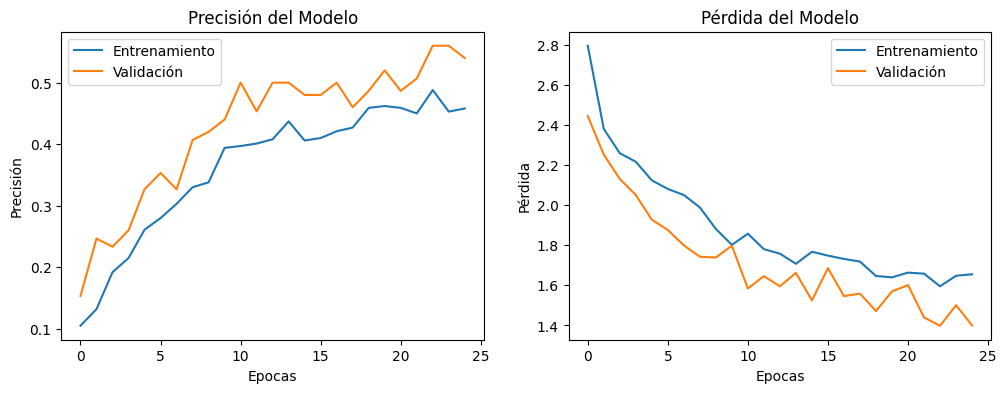

Diagnóstico: Buen ajuste


In [6]:
# ============================
# 6. VISUALIZACIÓN DE MÉTRICAS
# ============================
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión del Modelo')
plt.xlabel('Epocas')
plt.ylabel('Precisión')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida del Modelo')
plt.xlabel('Epocas')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

# Diagnóstico del modelo: overfitting, underfitting o buen ajuste
train_loss_final = history.history['loss'][-1]
val_loss_final = history.history['val_loss'][-1]

if val_loss_final > train_loss_final * 1.3:
    print("Diagnóstico: Overfitting")
elif val_loss_final < train_loss_final * 0.7:
    print("Diagnóstico: Underfitting")
else:
    print("Diagnóstico: Buen ajuste")


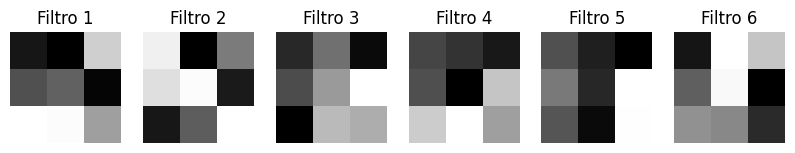

In [7]:
# ============================
# 7. VISUALIZACIÓN DE FILTROS
# ============================
first_conv_layer = model.layers[0]  # Obtener la primera capa convolucional
filters, biases = first_conv_layer.get_weights()  # Obtener filtros

# Normalizar valores para visualizar mejor
f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max - f_min)

n_filters = 6  # Número de filtros a mostrar
plt.figure(figsize=(10, 4))
for i in range(n_filters):
    f = filters[:, :, :, i]  # Seleccionar filtro i
    plt.subplot(1, n_filters, i + 1)
    plt.imshow(f[:, :, 0], cmap='gray')  # Mostrar un canal (RGB)
    plt.axis('off')
    plt.title(f'Filtro {i+1}')
plt.show()